In [1]:
from plots import plot_policy_convergence, plot_final_policies, plot_final_policies_linear, plot_specific_state_policy, plot_specific_state_policy_linear
from plots import plot_policy, plot_transition_matrix
import pickle

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import copy
from pathlib import Path

In [3]:
import os
os.getcwd()

'/Users/mathis/Documents/EPFL/Master_Thesis/CARMA-Congestion_Railway/0-Simulation'

In [4]:
path = "../results_0/"

with open(path + 'groups.pkl', 'rb') as f:
    groups = pickle.load(f)

with open(path + 'error_vec.pkl', 'rb') as f:
    error_vec = pickle.load(f)

with open(path + 'expected_value_vec.pkl', 'rb') as f:
    expected_value_vec = pickle.load(f)

with open(path + 'simulation_params.pkl', 'rb') as f:
    n_day, n_groups, K, n_travelers = pickle.load(f)

with open(path + 'system.pkl', 'rb') as f:
    system = pickle.load(f)

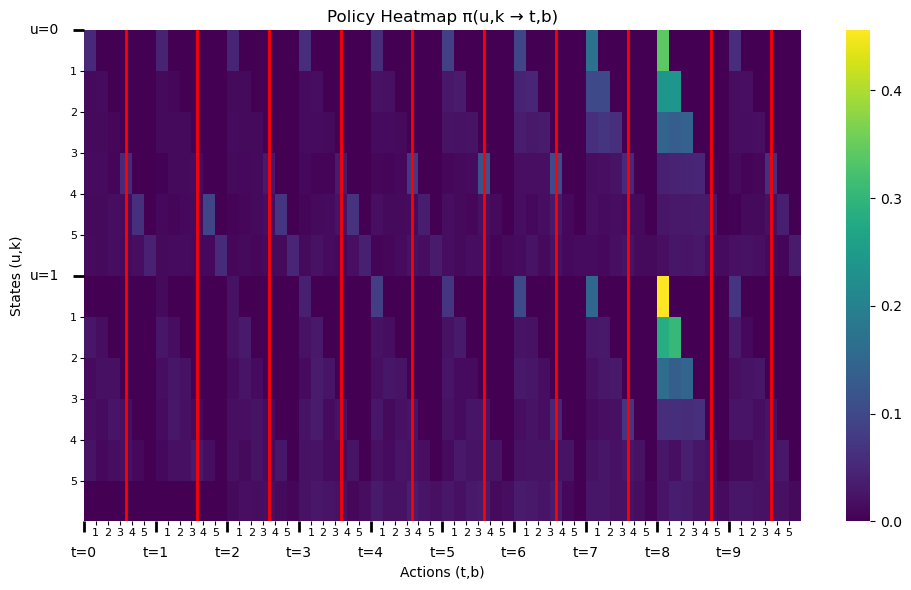

In [5]:
group = groups[0]

# plot_policy(group, b_star=system.b_star)  # full matrix
max_karma_level = 5 # for plotting
k_list = list(range(max_karma_level + 1))
b_list = k_list
plot_policy(group, u=[0,1], k=k_list, t=None, b=b_list, b_star=system.b_star)


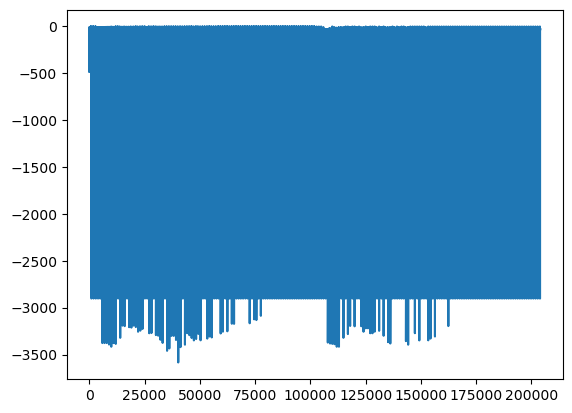

In [6]:
plt.plot(group.Q)

In [7]:
for i in range(group.U * (group.K+1)): 
            k = i % (group.K+1)
            u = i // (group.K+1)
            for t in range(group.T):
                for b in range(group.K + 1):
                    action_index = t*(group.K+1) + b
                    if (u ==0 and k ==1):
                        print(f"State (u={u}, k={k}), Action (t={t}, b={b}), Q-value: {group.Q[u*(group.K+1)*group.T*(group.K+1) + action_index]}, Policy: {group.pi[u*(group.K+1) + k,action_index]}")


State (u=0, k=1), Action (t=0, b=0), Q-value: -483.58316780083464, Policy: 0.011118975467979908
State (u=0, k=1), Action (t=0, b=1), Q-value: -8.0, Policy: 0.013540131039917469
State (u=0, k=1), Action (t=0, b=2), Q-value: -8.0, Policy: 0.0
State (u=0, k=1), Action (t=0, b=3), Q-value: -8.058950199529727, Policy: 0.0
State (u=0, k=1), Action (t=0, b=4), Q-value: -10.169940802469137, Policy: 0.0
State (u=0, k=1), Action (t=0, b=5), Q-value: -10.169940802469137, Policy: 0.0
State (u=0, k=1), Action (t=0, b=6), Q-value: -10.169940802469137, Policy: 0.0
State (u=0, k=1), Action (t=0, b=7), Q-value: -10.169940802469137, Policy: 0.0
State (u=0, k=1), Action (t=0, b=8), Q-value: -10.169940802469137, Policy: 0.0
State (u=0, k=1), Action (t=0, b=9), Q-value: -10.169940802469137, Policy: 0.0
State (u=0, k=1), Action (t=0, b=10), Q-value: -10.169940802469137, Policy: 0.0
State (u=0, k=1), Action (t=0, b=11), Q-value: -10.169940802469137, Policy: 0.0
State (u=0, k=1), Action (t=0, b=12), Q-value: 

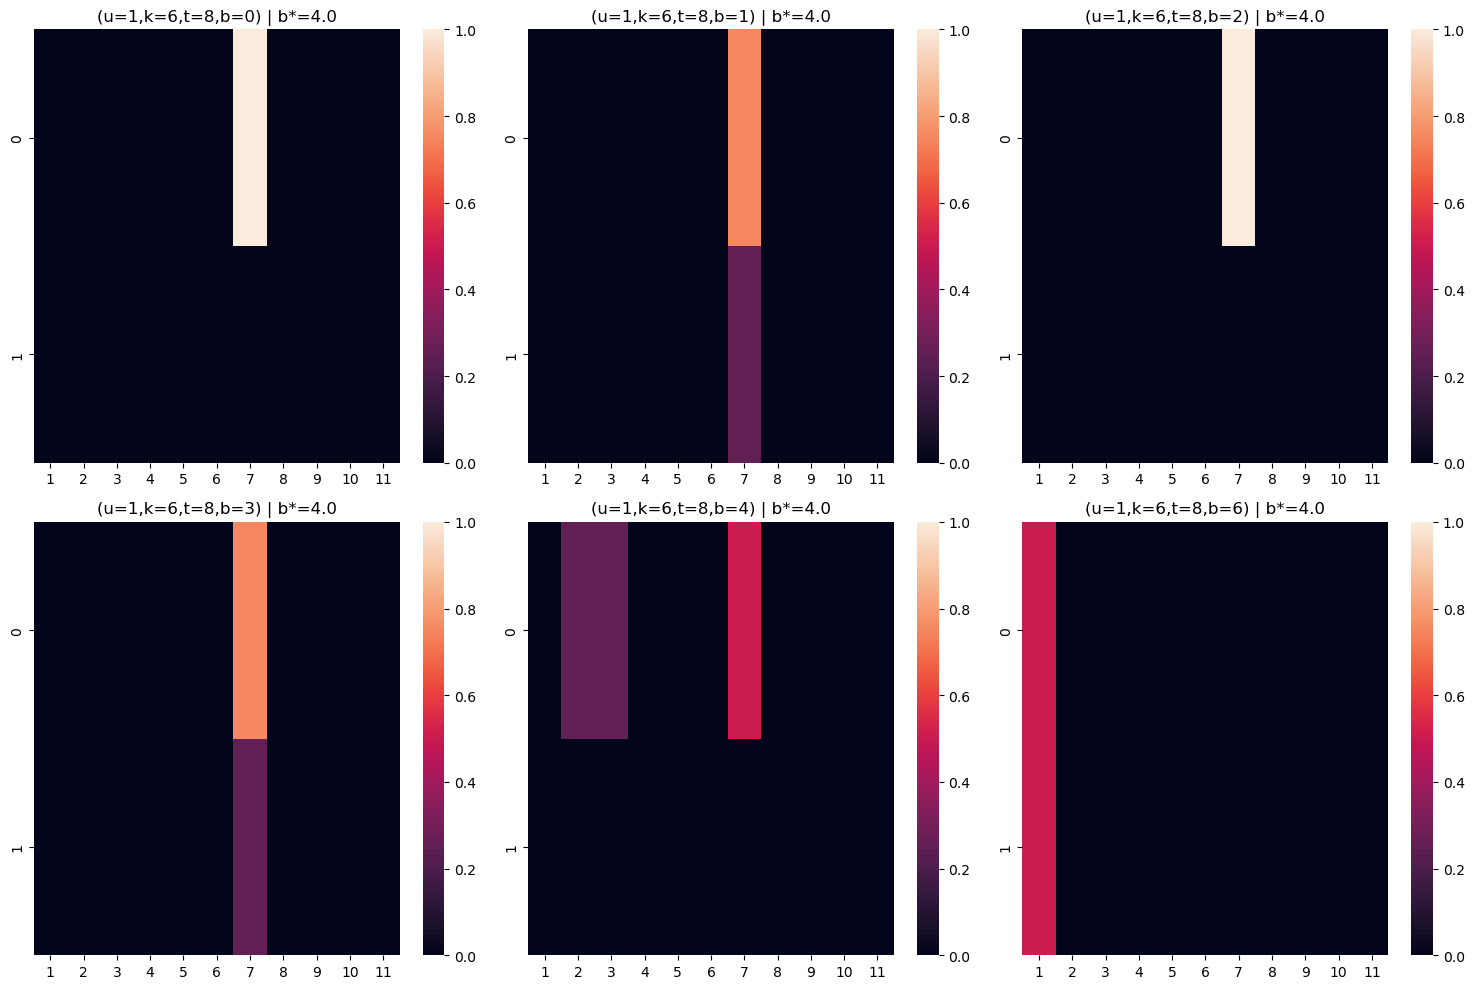

In [8]:
plot_transition_matrix(group, u=1, k=[6], t=8, b=[0,1,2,3,4,6], b_star=system.b_star)


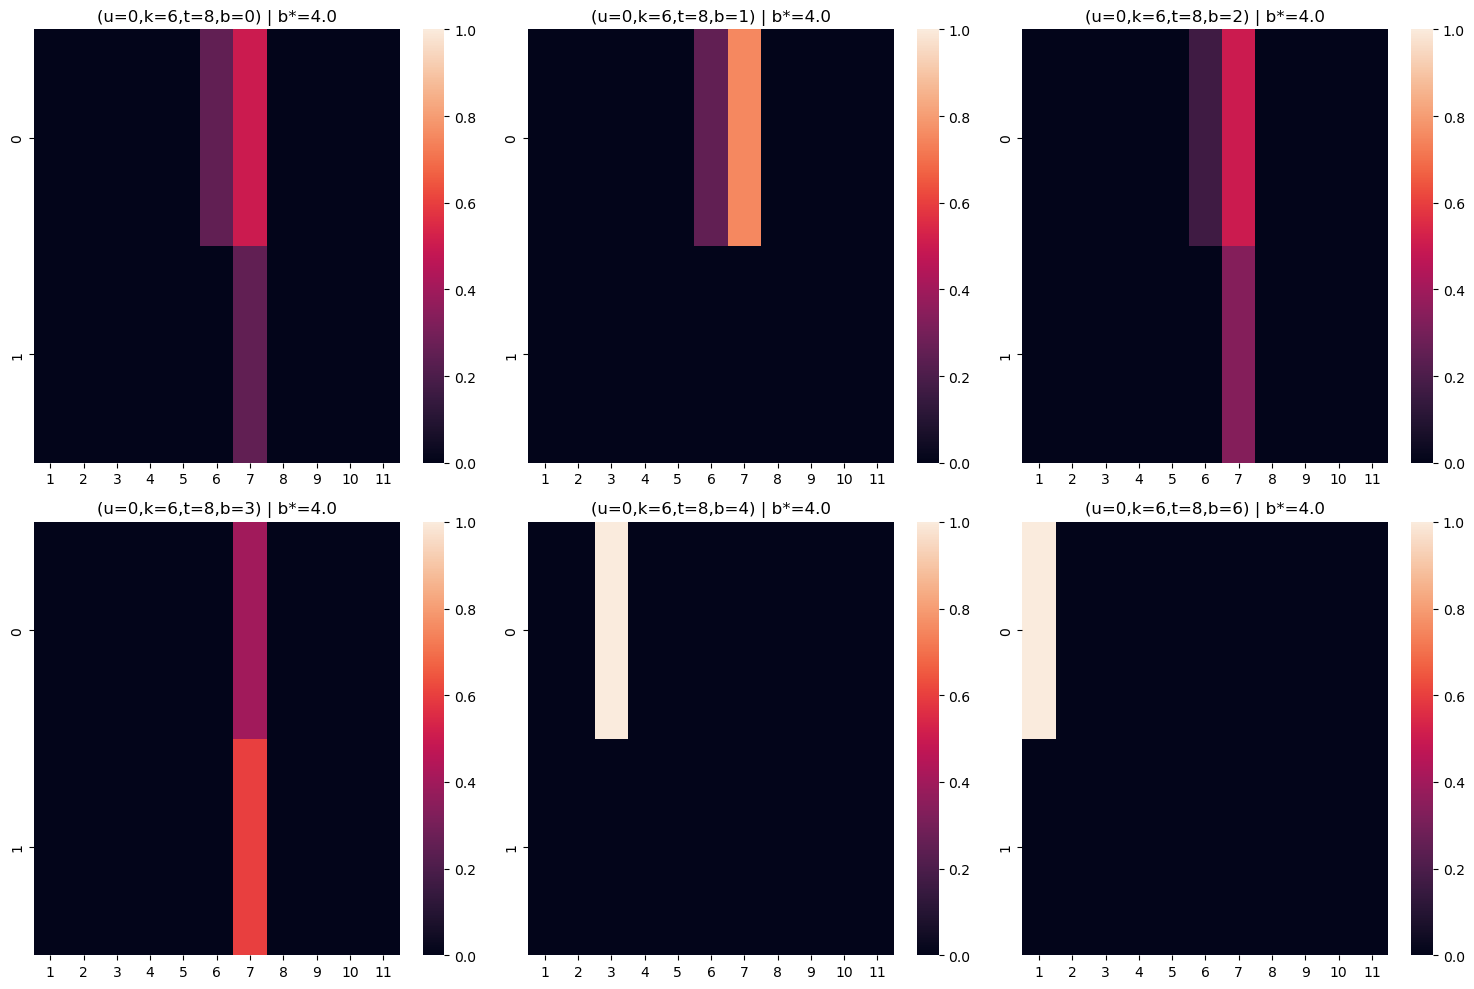

In [9]:
plot_transition_matrix(group, u=0, k=[6], t=8, b=[0,1,2,3,4,6], b_star=system.b_star)

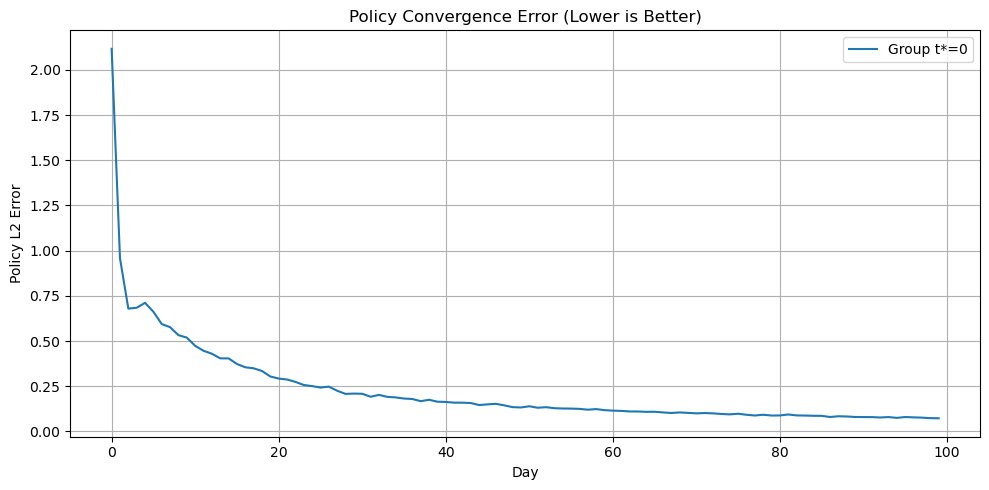

In [10]:
plot_policy_convergence(error_vec, n_day, n_groups)

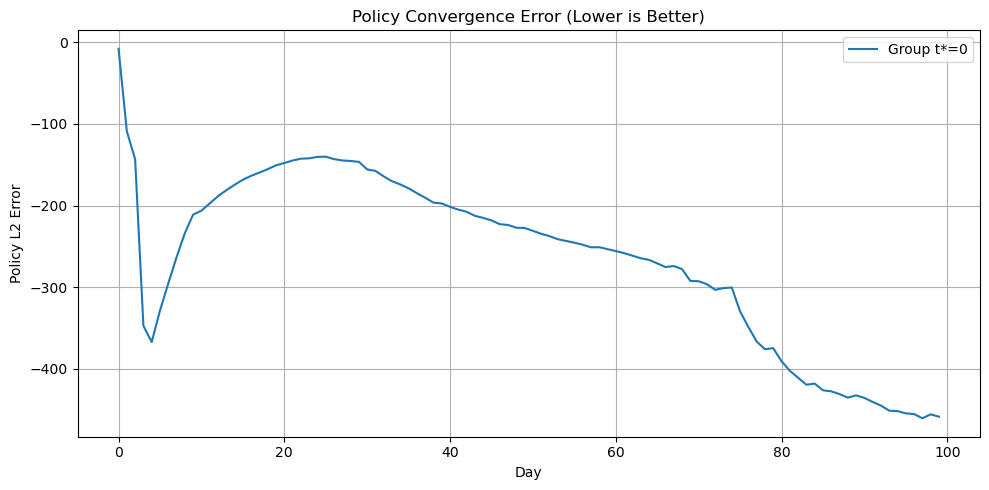

In [11]:
# for expected_value_vec
plot_policy_convergence(expected_value_vec, n_day, n_groups)

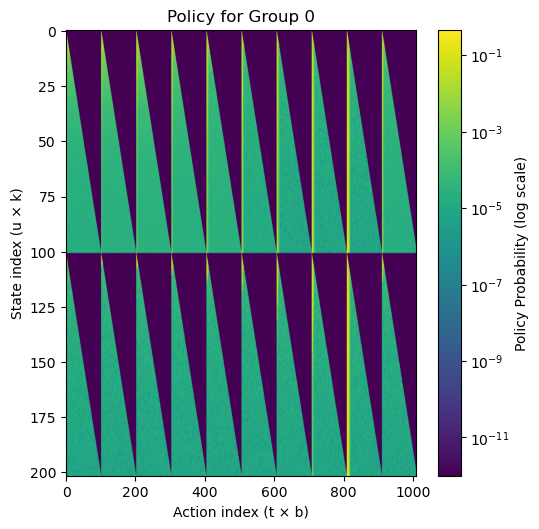

In [12]:
plot_final_policies(groups, n_groups)

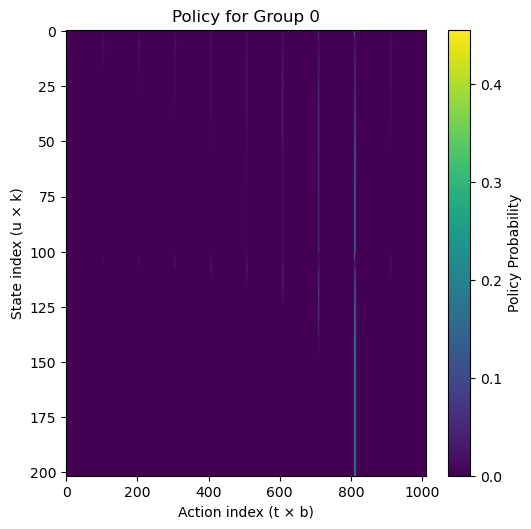

In [13]:
plot_final_policies_linear(groups, n_groups)

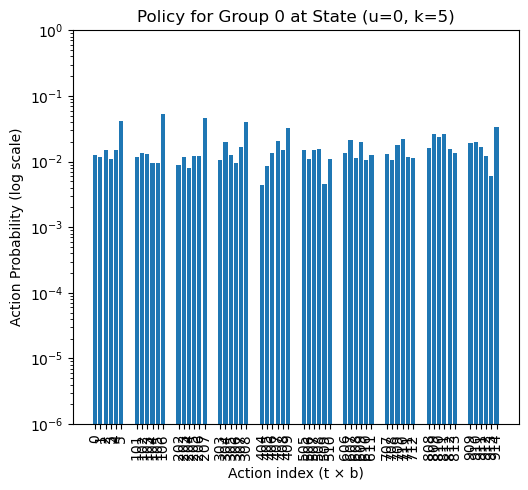

In [14]:
specific_u = 0
specific_k = 5

plot_specific_state_policy(groups, n_groups, K, specific_u, specific_k)

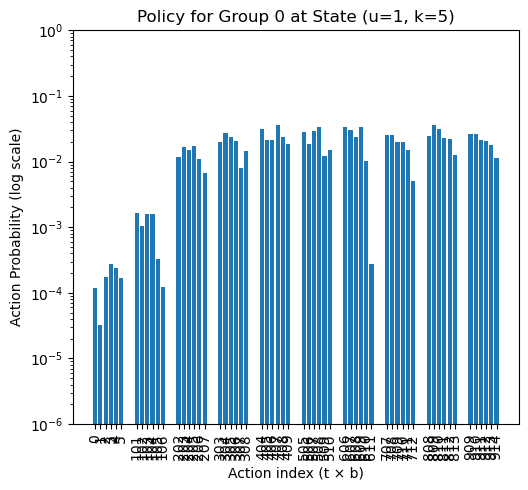

In [15]:
specific_u = 1
plot_specific_state_policy(groups, n_groups, K, specific_u, specific_k)

TypeError: TravelerGroup.update_group_attributes() missing 1 required positional argument: 'n_day'

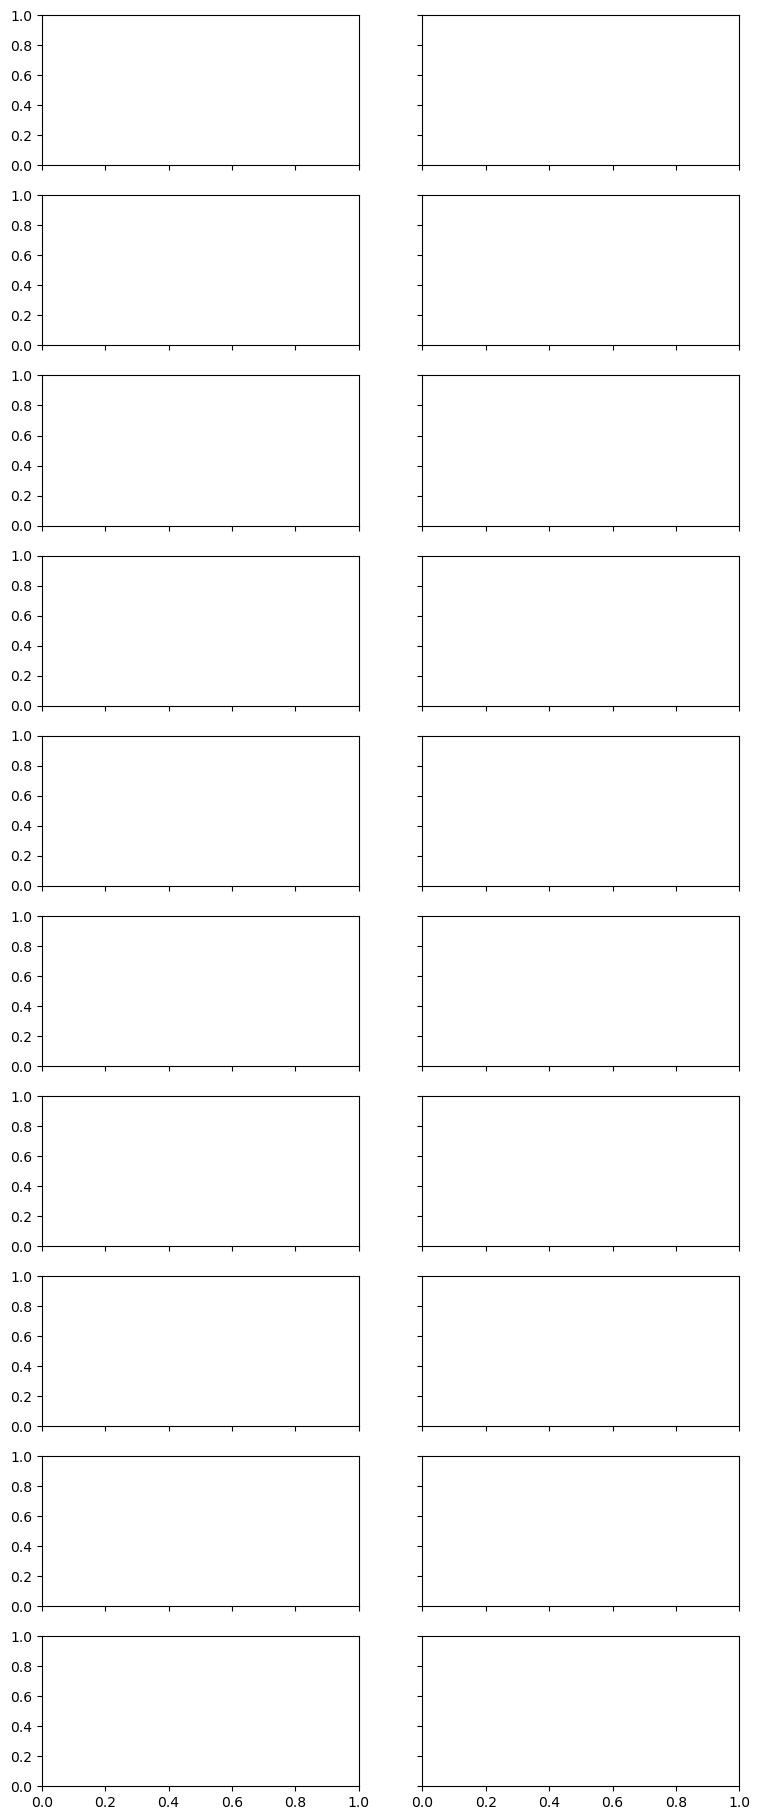

In [16]:
import matplotlib.pyplot as plt
import numpy as np

n_iter = 10
u_values = [0, 1]
k = K
T = groups[0].T

fig, axes = plt.subplots(
    n_iter, 2,
    figsize=(9, 2.3 * n_iter),
    sharex=True, sharey=True
)

for it in range(n_iter):

    # ---- Store policy BEFORE update ----
    pi_before = {}
    for u in u_values:
        idx = u * (K + 1) + k
        pi_before[u] = groups[0].pi[idx].reshape(T, K+1).T

    # ---- One-day simulation ----
    travelers = groups[0].travelers

    # 1. Travelers act
    for tr in travelers:
        tr.store_start_state()
        tr.action()

    # 2. System queues
    system.simulate_class_attribution()

    # 3. Payment
    for tr in travelers:
        tr.paid_karma_bid()

    # 4. Redistribution
    system.karma_redistribution()

    # 5. Update urgency
    for tr in travelers:
        tr.update_urgency()

    # 6. Update each group (independent policies)
    for g in groups:
        g.update_group_attributes(system) 

        g.update_state_distribution()
        g.compute_expected_value_function()


    # ---- Plot ----
    for col, u in enumerate(u_values):
        ax = axes[it, col]

        im = ax.imshow(
            pi_before[u][:11],
            origin="lower",
            aspect="auto",
            vmin=0,
            vmax=0.1
        )

        if it == 0:
            ax.set_title(f"Urgency $u={u}$")

        if col == 0:
            ax.set_ylabel(f"Iter {it}\nBid $b$")

        if it == n_iter - 1:
            ax.set_xlabel("Departure time $t$")

# ---- Manual layout control ----
plt.subplots_adjust(
    left=0.08,
    right=0.88,
    top=0.92,
    bottom=0.08,
    hspace=0.35,
    wspace=0.15
)

# ---- Dedicated colorbar axis ----
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Policy probability")

plt.show()
